## 0. INPUT — Giảng viên chỉ cần nhập chuỗi tọa độ

In [12]:

# Ví dụ vẽ số 2
POINTS = [
    # (1, 6),
    # (5, 6),
    # (4, 4),
    # (1, 0),
    # (5, 0)
    (1, 6),
    (5, 5)
]
CM_PER_UNIT = 1.0
X_AXIS_SIGN = 1
Y_AXIS_SIGN = 1
SIMULATION_SPEED = 1.0
MOTOR_SPEED = 0.20
MAX_MOVE_TIME = 10.0
TURN_SPEED = 0.20
LINEAR_SPEED_MPS = 0.20
ANGULAR_SPEED_RAD_S = 1.0

PAUSE_BETWEEN_SEGMENTS = 0.3

print("POINTS =", POINTS)
print("Số đoạn =", len(POINTS) - 1)


POINTS = [(1, 6), (5, 5)]
Số đoạn = 1


In [13]:

import math
import matplotlib.pyplot as plt

def vector_subtract(a, b):
    return (a[0] - b[0], a[1] - b[1])

def vector_add(a, b):
    return (a[0] + b[0], a[1] + b[1])

def scalar_multiply(k, v):
    return (k * v[0], k * v[1])

def magnitude(v):
    return math.sqrt(v[0]**2 + v[1]**2)

def angle_deg(v):
    return math.degrees(math.atan2(v[1], v[0]))

def calculate_vectors(points):
    result = []
    for i in range(len(points) - 1):
        p1 = points[i]
        p2 = points[i + 1]
        v = vector_subtract(p2, p1)

        result.append({
            "step": i + 1,
            "from": p1,
            "to": p2,
            "vector": v,
            "distance_unit": magnitude(v),
            "distance_cm": magnitude(v) * CM_PER_UNIT,
            "angle_deg": angle_deg(v)
        })
    return result

vectors = calculate_vectors(POINTS)

print(f"{'Step':<6}{'From':<12}{'To':<12}{'Vector':<15}{'Distance':<14}{'Angle':>10}")
print("-" * 75)

for item in vectors:
    print(
        f"{item['step']:<6}"
        f"{str(item['from']):<12}"
        f"{str(item['to']):<12}"
        f"{str(item['vector']):<15}"
        f"{item['distance_cm']:<14.2f}"
        f"{item['angle_deg']:>9.2f}°"
    )


Step  From        To          Vector         Distance           Angle
---------------------------------------------------------------------------
1     (1, 6)      (5, 5)      (4, -1)        4.12             -14.04°


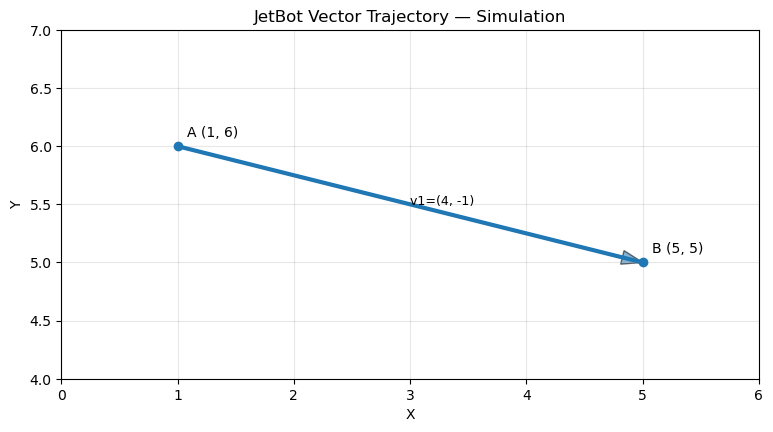

In [14]:

def plot_trajectory(points, vectors=None):
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]

    fig, ax = plt.subplots(figsize=(9, 9))

    ax.plot(xs, ys, marker="o", linewidth=3)

    for i, p in enumerate(points):
        label = chr(65 + i) if i < 26 else str(i)
        ax.annotate(
            f"{label} {p}",
            p,
            xytext=(7, 7),
            textcoords="offset points",
            fontsize=10
        )

    if vectors:
        for item in vectors:
            x1, y1 = item["from"]
            x2, y2 = item["to"]

            ax.arrow(
                x1, y1,
                x2-x1, y2-y1,
                length_includes_head=True,
                head_width=0.12,
                alpha=0.55
            )

            mx = (x1 + x2) / 2
            my = (y1 + y2) / 2

            ax.text(
                mx, my,
                f"v{item['step']}={item['vector']}",
                fontsize=9
            )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title("JetBot Vector Trajectory — Simulation")
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")

    margin = 1
    ax.set_xlim(min(xs) - margin, max(xs) + margin)
    ax.set_ylim(min(ys) - margin, max(ys) + margin)

    plt.show()

plot_trajectory(POINTS, vectors)


## 1.2. Kiểm tra Vector Addition

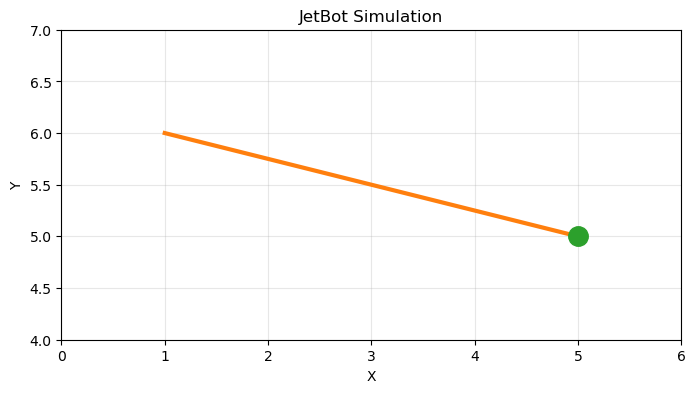

In [16]:

import time
from IPython.display import display, clear_output

def animate_trajectory(points, frames_per_unit=8, delay=0.03):
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(min(xs)-1, max(xs)+1)
    ax.set_ylim(min(ys)-1, max(ys)+1)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title("JetBot Simulation")

    ax.plot(xs, ys, linestyle="--", alpha=0.25)

    trail_x = [xs[0]]
    trail_y = [ys[0]]

    trail, = ax.plot(trail_x, trail_y, linewidth=3)
    robot, = ax.plot([xs[0]], [ys[0]], marker="o", markersize=14)

    for i in range(len(points)-1):
        x0, y0 = points[i]
        x1, y1 = points[i+1]

        dist = magnitude((x1-x0, y1-y0))
        n = max(2, int(dist * frames_per_unit))

        for j in range(1, n+1):
            t = j/n
            x = x0 + t*(x1-x0)
            y = y0 + t*(y1-y0)

            trail_x.append(x)
            trail_y.append(y)

            trail.set_data(trail_x, trail_y)
            robot.set_data([x], [y])

            clear_output(wait=True)
            display(fig)
            time.sleep(delay)

    clear_output(wait=True)
    # display(fig)

animate_trajectory(POINTS)


In [ ]:

# Cell này dành cho JetBot thật.
#
# Với Waveshare JetBot, API thường gặp là:
#     from jetbot import Robot
#     robot = Robot()
#
# Nếu image JetBot của bạn sử dụng API khác,
# chỉ cần thay phần import / khởi tạo ở cell này.

try:
    from jetbot import Robot
    robot = Robot()
    JETBOT_AVAILABLE = True
    print("✅ JetBot API đã được import.")
except Exception as e:
    robot = None
    JETBOT_AVAILABLE = False
    print("⚠️ Chưa kết nối được JetBot API.")
    print("Lỗi:", repr(e))
    print()
    print("Notebook vẫn có thể chạy PHẦN 1.")


## 2.2. Hàm STOP khẩn cấp

In [ ]:

def stop_robot():
    if robot is not None:
        robot.stop()
    print("🛑 JETBOT STOPPED")

print("Hàm stop_robot() đã sẵn sàng.")
print("Nếu có vấn đề, chạy:")
print("    stop_robot()")

def test_forward(distance_cm=20):
    if robot is None:
        print("❌ JetBot chưa được kết nối.")
        return

    distance_m = distance_cm / 100.0
    duration = distance_m / LINEAR_SPEED_MPS
    duration = min(duration, MAX_MOVE_TIME)

    print(f"Robot sẽ chạy khoảng {distance_cm} cm trong {duration:.2f} s.")
    print("Hãy đảm bảo phía trước hoàn toàn trống.")

    robot.forward(MOTOR_SPEED)
    time.sleep(duration)
    robot.stop()

    print("✅ Test hoàn thành.")

In [ ]:

def normalize_angle_deg(angle):
    while angle > 180:
        angle -= 360
    while angle < -180:
        angle += 360
    return angle

def turn_in_place(angle_deg):
    if robot is None:
        raise RuntimeError("JetBot chưa được kết nối.")

    angle_deg = normalize_angle_deg(angle_deg)

    if abs(angle_deg) < 0.5:
        return

    angle_rad = math.radians(abs(angle_deg))
    duration = angle_rad / ANGULAR_SPEED_RAD_S
    duration = min(duration, MAX_MOVE_TIME)

    # Quy ước:
    # angle > 0: quay trái
    # angle < 0: quay phải
    if angle_deg > 0:
        robot.left(TURN_SPEED)
    else:
        robot.right(TURN_SPEED)

    time.sleep(duration)
    robot.stop()
    time.sleep(PAUSE_BETWEEN_SEGMENTS)


def move_forward(distance_cm):
    if robot is None:
        raise RuntimeError("JetBot chưa được kết nối.")

    if distance_cm < 0:
        # Không dùng trong pipeline chính, nhưng hỗ trợ nếu cần
        robot.backward(MOTOR_SPEED)
        duration = abs(distance_cm) / 100.0 / LINEAR_SPEED_MPS
    else:
        robot.forward(MOTOR_SPEED)
        duration = distance_cm / 100.0 / LINEAR_SPEED_MPS

    duration = min(duration, MAX_MOVE_TIME)

    time.sleep(duration)
    robot.stop()
    time.sleep(PAUSE_BETWEEN_SEGMENTS)


def run_vector(vector, current_heading_deg=0):
    dx, dy = vector

    # Tính hướng của vector trong hệ tọa độ bàn
    target_angle_deg = math.degrees(math.atan2(dy, dx))

    # Góc cần quay tương đối so với hướng hiện tại
    relative_angle = normalize_angle_deg(
        target_angle_deg - current_heading_deg
    )

    distance_cm = magnitude(vector) * CM_PER_UNIT

    print(f"Vector = {vector}")
    print(f"Distance = {distance_cm:.2f} cm")
    print(f"Target heading = {target_angle_deg:.2f}°")
    print(f"Turn = {relative_angle:.2f}°")

    turn_in_place(relative_angle)
    move_forward(distance_cm)

    return target_angle_deg


In [ ]:

# Chọn bước muốn chạy:
STEP_TO_RUN = 1

if 1 <= STEP_TO_RUN <= len(vectors):
    item = vectors[STEP_TO_RUN - 1]

    print("STEP", item["step"])
    print("From:", item["from"])
    print("To:", item["to"])
    print("Vector:", item["vector"])

    # ⚠️ Bỏ comment dòng dưới khi muốn robot chạy thật.
    #
    # run_vector(item["vector"])

else:
    print("STEP không hợp lệ.")


In [ ]:

def run_full_trajectory(points, vectors):
    if robot is None:
        raise RuntimeError("JetBot chưa được kết nối.")

    heading = 0.0

    print("🤖 STARTING REAL JETBOT")
    print(f"Số đoạn: {len(vectors)}")
    print("Ctrl+C hoặc chạy stop_robot() nếu cần dừng.")
    print()

    try:
        for item in vectors:
            print("=" * 60)
            print(f"STEP {item['step']}")
            print(f"{item['from']} → {item['to']}")

            heading = run_vector(
                item["vector"],
                current_heading_deg=heading
            )

        robot.stop()
        print("=" * 60)
        print("✅ HOÀN THÀNH QUỸ ĐẠO")

    except KeyboardInterrupt:
        robot.stop()
        print()
        print("🛑 ĐÃ DỪNG BẰNG KEYBOARD INTERRUPT")

    except Exception as e:
        robot.stop()
        print()
        print("🛑 ROBOT ĐÃ DỪNG DO LỖI")
        raise e


# ============================================================
# ⚠️ CHỈ BỎ COMMENT SAU KHI ĐÃ KIỂM TRA SIMULATION
# ============================================================

# run_full_trajectory(POINTS, vectors)
